# GEOG 592 — Week 7 Homework
## GeoPandas Geoprocessing Techniques



In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

### Layer 1: Chargers in Chapel Hill and Surrounding Counties

In [3]:
# Read data
raw_chargers = gpd.read_file("data/chargers.geojson")

raw_chargers

,access_code,access_days_time,access_detail_code,cards_accepted,date_last_confirmed,expected_date,fuel_type_code,groups_with_access_code,id,maximum_vehicle_class,...,nps_unit_name,access_days_time_fr,intersection_directions_fr,bd_blends_fr,groups_with_access_code_fr,ev_pricing_fr,ev_charging_units,ev_network_ids,federal_agency,geometry
0,public,24 hours daily; metered parking,NaN,NaN,2026-06-12,None,ELEC,Public,39016,MD,...,NaN,None,None,None,Public,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN,POINT (-78.64347 35.77842)
1,public,24 hours daily,NaN,NaN,2026-06-12,None,ELEC,Public,39017,LD,...,NaN,None,None,None,Public,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN,POINT (-78.64229 35.77435)
2,public,Dealership business hours,CALL,NaN,2024-02-12,None,ELEC,Public - Call ahead,40066,LD,...,NaN,None,None,None,Public - Appeler à l'avance,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN,POINT (-80.62277 35.39209)
3,public,24 hours daily; for guest use only,NaN,NaN,2026-09-14,None,ELEC,Public,40745,LD,...,NaN,None,None,None,Public,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN,POINT (-78.6385 35.77288)
4,public,24 hours daily; pay garage,NaN,NaN,2026-06-12,None,ELEC,Public,40747,LD,...,NaN,None,None,None,Public,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN,POINT (-78.64149 35.77262)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1879,public,Mon: 7:00am-3:00pm; Tue: 7:00am-3:00pm; Wed: 7...,NaN,NaN,2026-10-04,None,ELEC,Public,470511,NaN,...,NaN,None,None,None,Public,None,"[{'network': 'ChargePoint Network', 'connector...","{'station': ['USCPIL18283671'], 'posts': ['283...",NaN,POINT (-78.81147 35.68686)
1880,public,Mon: 7:00am-3:00pm; Tue: 7:00am-3:00pm; Wed: 7...,NaN,NaN,2026-10-04,None,ELEC,Public,470512,NaN,...,NaN,None,None,None,Public,None,"[{'network': 'ChargePoint Network', 'connector...","{'station': ['USCPIL18283721'], 'posts': ['283...",NaN,POINT (-78.8114 35.68688)
1881,public,24 hours daily,NaN,NaN,2026-10-04,None,ELEC,Public,470688,NaN,...,NaN,None,None,None,Public,None,"[{'network': 'IONNA', 'connectors': {'J1772': ...",{'station': ['953eb9ef-5663-4ace-83d3-92380dd5...,NaN,POINT (-80.48826 35.63111)
1882,public,24 hours daily,NaN,NaN,2026-10-04,None,ELEC,Public,470760,NaN,...,NaN,None,None,None,Public,None,"[{'network': 'ChargePoint Network', 'connector...","{'station': ['USCPIL20294791'], 'posts': ['316...",NaN,POINT (-80.87586 35.1927)


In [4]:
# Indentify CRS
raw_chargers.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [5]:
# Column names
raw_chargers.columns

Index(['access_code', 'access_days_time', 'access_detail_code',
       'cards_accepted', 'date_last_confirmed', 'expected_date',
       'fuel_type_code', 'groups_with_access_code', 'id',
       'maximum_vehicle_class', 'open_date', 'owner_type_code',
       'related_stations', 'restricted_access', 'status_code',
       'funding_sources', 'facility_type', 'station_name', 'station_phone',
       'updated_at', 'geocode_status', 'city', 'country',
       'intersection_directions', 'plus4', 'state', 'street_address', 'zip',
       'bd_blends', 'cng_dispenser_num', 'cng_fill_type_code', 'cng_has_rng',
       'cng_psi', 'cng_renewable_source', 'cng_total_compression',
       'cng_total_storage', 'cng_vehicle_class', 'e85_blender_pump',
       'e85_other_ethanol_blends', 'ev_connector_types', 'ev_dc_fast_num',
       'ev_level1_evse_num', 'ev_level2_evse_num', 'ev_network',
       'ev_network_web', 'ev_other_evse', 'ev_pricing', 'ev_renewable_source',
       'ev_workplace_charging', 'hy_is_ret

#### Columns of Interest
* 'fuel_type_code'
* 'id'
* 'station_name'
* 'geometry'

In [6]:
# Check data
print(raw_chargers[["station_name","fuel_type_code","geometry"]])
print(type(raw_chargers[["station_name","fuel_type_code","geometry"]]))

                                           station_name fuel_type_code  \
0                  City of Raleigh - Municipal Building           ELEC   
1                            City of Raleigh - Downtown           ELEC   
2                               Modern Nissan - Concord           ELEC   
3                     Marriott Hotel - Underground Deck           ELEC   
4         City of Raleigh - Performing Arts Center Deck           ELEC   
...                                                 ...            ...   
1879                               WCPSS FELTON GROVE 3           ELEC   
1880                               WCPSS FELTON GROVE 2           ELEC   
1881  Salisbury, NC Rechargery Relay @ Circle K -Row...           ELEC   
1882                                    PPS MAASTATION1           ELEC   
1883                                    PPS MAASTATION2           ELEC   

                        geometry  
0     POINT (-78.64347 35.77842)  
1     POINT (-78.64229 35.77435)  
2     

In [7]:
# Filtering only columns of interest
chargers = raw_chargers[["station_name","geometry"]].copy()
chargers

,station_name,geometry
0,City of Raleigh - Municipal Building,POINT (-78.64347 35.77842)
1,City of Raleigh - Downtown,POINT (-78.64229 35.77435)
2,Modern Nissan - Concord,POINT (-80.62277 35.39209)
3,Marriott Hotel - Underground Deck,POINT (-78.6385 35.77288)
4,City of Raleigh - Performing Arts Center Deck,POINT (-78.64149 35.77262)
...,...,...
1879,WCPSS FELTON GROVE 3,POINT (-78.81147 35.68686)
1880,WCPSS FELTON GROVE 2,POINT (-78.8114 35.68688)
1881,"Salisbury, NC Rechargery Relay @ Circle K -Row...",POINT (-80.48826 35.63111)
1882,PPS MAASTATION1,POINT (-80.87586 35.1927)


In [8]:
raw_counties = gpd.read_file("data/counties.geojson")

print(raw_counties.geom_type)
print(raw_counties.crs)
raw_counties

0     Polygon
1     Polygon
2     Polygon
3     Polygon
4     Polygon
       ...   
95    Polygon
96    Polygon
97    Polygon
98    Polygon
99    Polygon
Length: 100, dtype: str
EPSG:4326


,OBJECTID,FIPS,CountyName,UpperCountyName,SapCountyId,DOTDistrictID,DOTDivisionID,SAP_CNTY_NBR,CNTY_NBR,DSTRCT_NBR,DIV_NBR,NAME,Shape.STArea(),Shape.STLength(),SHPNumber,geometry
0,1,1,Alamance,ALAMANCE,001,1,7,1,0,1,7,Alamance,1.210717e+10,476733.362073,1,"POLYGON ((-79.25882 36.17252, -79.25752 36.237..."
1,2,3,Alexander,ALEXANDER,002,2,12,2,1,2,12,Alexander,7.343450e+09,387342.137292,2,"POLYGON ((-81.10951 35.7766, -81.10801 35.7775..."
2,3,5,Alleghany,ALLEGHANY,003,1,11,3,2,1,11,Alleghany,6.576362e+09,439166.717185,3,"POLYGON ((-81.25365 36.3666, -81.25314 36.3666..."
3,4,7,Anson,ANSON,004,3,10,4,3,3,10,Anson,1.497020e+10,575503.754866,4,"POLYGON ((-80.27683 35.19573, -80.27686 35.195..."
4,5,9,Ashe,ASHE,005,3,11,5,4,3,11,Ashe,1.193926e+10,520084.244333,5,"POLYGON ((-81.47731 36.24026, -81.46461 36.256..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,191,Wayne,WAYNE,096,3,4,96,95,3,4,Wayne,1.554411e+10,579779.305793,96,"POLYGON ((-77.99869 35.58567, -77.99901 35.585..."
96,97,193,Wilkes,WILKES,097,3,11,97,96,3,11,Wilkes,2.111152e+10,718180.039408,97,"POLYGON ((-81.30257 36.00491, -81.30244 36.004..."
97,98,195,Wilson,WILSON,098,2,4,98,97,2,4,Wilson,1.039961e+10,430628.770432,98,"POLYGON ((-77.82251 35.58539, -77.82232 35.585..."
98,99,197,Yadkin,YADKIN,099,1,11,99,98,1,11,Yadkin,9.415514e+09,452687.390790,99,"POLYGON ((-80.49555 36.04597, -80.49601 36.046..."


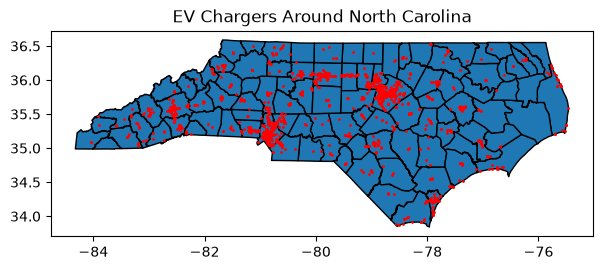

In [9]:
# Plotting all NC counties
fig, ax = plt.subplots(figsize=(7,7))
raw_counties.plot(ax=ax, edgecolor="black")
chargers.plot(ax=ax, markersize=1, c="red")
ax.set_title("EV Chargers Around North Carolina")
plt.show()

#### Filtering only counties near Chapel Hill
* 'Orange'
* 'Durham'
* 'Chatham'
* 'Alamance
* 'Person'
* 'Caswell'

In [10]:
# Filtering only columns of interest
counties = raw_counties[["NAME","geometry"]].copy()

In [18]:
# Filtering only rows of interest
counties_near_chap = counties[(counties['NAME'] == "Orange") | 
                     (counties['NAME'] == "Durham") | 
                     (counties['NAME'] == "Chatham") | 
                     (counties['NAME'] == "Alamance") | 
                     (counties['NAME'] == "Person") | 
                     (counties['NAME'] == "Caswell")].copy()

print(counties_near_chap)
print(type(counties_near_chap))

        NAME                                           geometry
0   Alamance  POLYGON ((-79.25882 36.17252, -79.25752 36.237...
16   Caswell  POLYGON ((-79.3646 36.5413, -79.36495 36.54131...
18   Chatham  POLYGON ((-79.0163 35.86322, -79.02524 35.8628...
31    Durham  POLYGON ((-78.80234 36.2358, -78.80268 36.2358...
67    Orange  POLYGON ((-78.9713 36.12121, -78.96626 36.15, ...
72    Person  POLYGON ((-78.79628 36.54175, -78.79662 36.541...
<class 'geopandas.geodataframe.GeoDataFrame'>


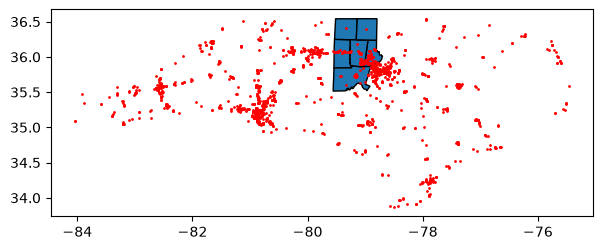

In [19]:
# Plotting only counties near Chapel Hill
fig, ax = plt.subplots(figsize=(7,7))
counties_near_chap.plot(ax=ax, edgecolor="black")
chargers.plot(ax=ax, markersize=1, c="red")
plt.show()

#### Finding chargers within selected counties

In [21]:
# make a "within" spatial selection 
chap_area = counties_near_chap.geometry.union_all()

near_chap = chargers.geometry.within(chap_area)

near_chap

0       False
1       False
2       False
3       False
4       False
        ...  
1879    False
1880    False
1881    False
1882    False
1883    False
Length: 1884, dtype: bool

In [ ]:
chargers[near_chap]

,station_name,geometry
6,Neal's Garage,POINT (-78.9214 36.01)
17,Carolina Nissan,POINT (-79.50374 36.06368)
25,Michael Jordan Nissan,POINT (-78.95687 35.97076)
42,Orange County - Robert and Pearl Seymour Center,POINT (-79.06335 35.95063)
43,Orange County - Durham Technical Community Col...,POINT (-79.09323 36.04236)
...,...,...
1819,Avalon Townhomes at Brier Creek,POINT (-78.80857 35.92353)
1832,Durham County North Library,POINT (-78.91444 36.08762)
1841,Knoll at Briar Chapel - Tesla Destination,POINT (-79.08794 35.815)
1842,Chatham Park YMCA - Tesla Destination,POINT (-79.14352 35.73562)


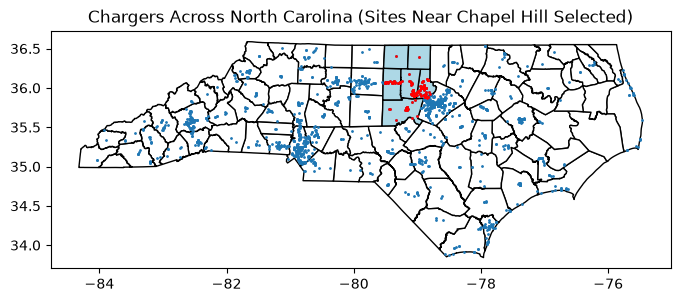

In [ ]:
fig, ax = plt.subplots(figsize=(8,7))
counties.plot(ax=ax, color="white", edgecolor="black")
near_chap.plot(ax=ax, color="lightblue", edgecolor="black")
chargers.plot(ax=ax, markersize=1)
chargers[near_chap].plot(ax=ax, markersize=1, c='red')
ax.set_title("Chargers Across North Carolina (Sites Near Chapel Hill Selected)")
plt.show()

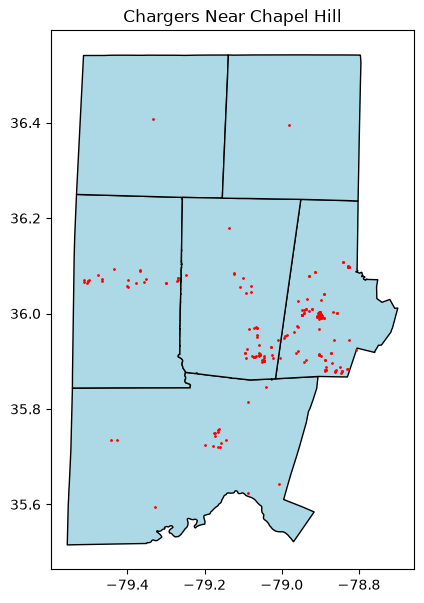

In [ ]:
fig, ax = plt.subplots(figsize=(8,7))
near_chap.plot(ax=ax, color="lightblue", edgecolor="black")
chargers[near_chap].plot(ax=ax, markersize=1, c='red')
ax.set_title("Chargers Near Chapel Hill")
plt.show()

#### Chapel Hill

In [ ]:
# Filtering only Chapel Hill
chap = counties[(counties['NAME'] == "Orange")].copy()

print(chap)

      NAME                                           geometry
67  Orange  POLYGON ((-78.9713 36.12121, -78.96626 36.15, ...


In [25]:
# make a "within" spatial selection 
chap = chap.geometry.union_all()

chap_chargers = chargers.geometry.within(chap)

chap_chargers

0       False
1       False
2       False
3       False
4       False
        ...  
1879    False
1880    False
1881    False
1882    False
1883    False
Length: 1884, dtype: bool

#### Counts

In [26]:
print("EV chargers in NC:", len(chargers))
print("EV chargers near Chapel Hill:", len(chargers[near_chap]))
print("EV chargers in Chapel Hill:", len(chargers[chap_chargers]))

EV chargers in NC: 1884
EV chargers near Chapel Hill: 207
EV chargers in Chapel Hill: 50


### Layer 2: Chargers Near Major Roads

## AI Usage
**Section: Filtering only rows of interest**\
Looked up why using "OR" was not selecting the rows of interest to learn "|" is used for pandas (Gemini)

**Section: make a "within" spatial selection**\
Received a warning message that my 'near_chap' object had multiple polygons so the performance of ".within" will be different than expected. Added the new 'chap_area' as a union of all polygons selected (ChatGPT)